In [1]:
import pandas as pd
import numpy as np


In [2]:
# Read the CSV file
file_path = '6-url_BERT_video_audio_features_4Categorey.csv'
df = pd.read_csv(file_path)

# Check the data
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())


Shape: (661, 3846)
Columns: ['url', 'title', 'label', 'comment_1', 'comment_2', 'comment_3', 'comment_4', 'comment_5', 'comment_6', 'comment_7', 'comment_8', 'comment_9', 'comment_10', 'comment_11', 'comment_12', 'comment_13', 'comment_14', 'comment_15', 'comment_16', 'comment_17', 'comment_18', 'comment_19', 'comment_20', 'comment_21', 'comment_22', 'comment_23', 'comment_24', 'comment_25', 'comment_26', 'comment_27', 'comment_28', 'comment_29', 'comment_30', 'comment_31', 'comment_32', 'comment_33', 'comment_34', 'comment_35', 'comment_36', 'comment_37', 'comment_38', 'comment_39', 'comment_40', 'comment_41', 'comment_42', 'comment_43', 'comment_44', 'comment_45', 'comment_46', 'comment_47', 'comment_48', 'comment_49', 'comment_50', 'comment_51', 'comment_52', 'comment_53', 'comment_54', 'comment_55', 'comment_56', 'comment_57', 'comment_58', 'comment_59', 'comment_60', 'comment_61', 'comment_62', 'comment_63', 'comment_64', 'comment_65', 'comment_66', 'comment_67', 'comment_68', 'co

In [3]:
df

,url,title,label,comment_1,comment_2,comment_3,comment_4,comment_5,comment_6,comment_7,...,audio_130,audio_131,audio_132,audio_133,audio_134,audio_135,audio_136,audio_137,audio_138,audio_139
0,https://youtube.com/shorts/aa4rZp_vfS4?si=2t9E...,ducking save seriously injured cat #duckrescue...,Explicit,-0.576433,0.106661,-0.415617,-0.291112,-0.484806,-0.031132,0.589751,...,-0.021403,0.102465,0.018431,0.167551,0.018082,0.166489,0.010044,0.055793,0.000368,0.058593
1,https://youtube.com/shorts/LBK1qGei-Sg?si=RiET...,🫣😄​أقوى المقاطع المضحكة للحمير – لن تتوقف عن ا...,Explicit,-0.383650,0.230333,-0.291540,-0.150749,-0.358716,-0.039360,0.578545,...,0.004436,0.048084,-0.009294,0.049872,0.014628,0.050712,0.002623,0.017251,0.002907,0.025290
2,https://youtube.com/shorts/Q304WXr0fDU?si=AYIe...,#momcozy#momlife#baby AA 501 #mother,Explicit,-0.294660,0.214890,-0.196700,-0.159281,-0.297902,-0.099254,0.411756,...,-0.116879,0.110252,-0.055603,0.102578,-0.028009,0.244705,-0.033516,0.061555,0.028123,0.076075
3,https://youtube.com/shorts/s6NJ-0lfRD8?si=qPbL...,🐐🤭#viralshots #youtubeshorts #goat #beautifull...,Explicit,-0.512111,0.230518,-0.319582,-0.173411,-0.343824,-0.078987,0.633583,...,-0.005206,0.107299,-0.016909,0.114603,-0.017748,0.100660,0.015117,0.039018,-0.007634,0.038970
4,https://youtube.com/shorts/YJQPjPWU0dM?si=BhqG...,01-Jul-26,Explicit,-0.539463,0.111179,-0.418902,-0.282552,-0.384801,0.016926,0.559527,...,-0.007741,0.074713,-0.017476,0.072241,-0.037804,0.046258,0.001086,0.022727,-0.031146,0.023914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,https://youtube.com/shorts/UHVRuJLmpeg?si=cQq6...,Riddhima Sharma vs Chandrika Dixit: Vada Pav G...,Toxic,-0.641037,0.003412,-0.364863,-0.311905,-0.519863,0.006760,0.590630,...,0.001411,0.127949,0.000591,0.191747,-0.002066,0.178739,0.003570,0.070858,-0.011562,0.060945
657,https://youtube.com/shorts/fjDUJNfHpaM?si=1XFr...,Riddhima Sharma ने kanika Sharma को बताया ब्रा...,Toxic,-0.728909,-0.076734,-0.344520,-0.315810,-0.548823,0.023216,0.513954,...,0.104536,0.096084,-0.164294,0.151530,0.018247,0.135776,-0.041684,0.055061,-0.034639,0.049502
658,https://youtube.com/shorts/DQ-py4VFjDI?si=efP5...,Riddhima sharma on rock #hindu #mamtabanerjee ...,Toxic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.007656,0.116003,-0.010736,0.164767,0.017211,0.145972,-0.001065,0.059322,-0.004482,0.053704
659,https://youtube.com/shorts/2b_XYeNIOQ0?si=x-C-...,A Haryana Girl Came to CJP Protest Jantar Mant...,Toxic,-0.593763,0.075582,-0.465600,-0.340069,-0.517657,0.021742,0.591004,...,-0.010695,0.134201,0.024080,0.189207,0.005616,0.200190,-0.008174,0.072525,-0.006270,0.062977


In [4]:
class_labels = df["label"].unique().tolist()
print(class_labels)

['Explicit', 'Toxic', 'Normal', 'Violence']


In [5]:
# Separate features, filename, and class ; first column is filename, last column is class
X = df.drop(columns=["url","title", "label"])
y = df["label"]

Lebel encoders

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([0, 0, 0, 0, 0, 2, 2, 1, 3, 0, 1, 3, 0, 1, 1, 1, 2, 0, 3, 0, 1, 1,
       0, 1, 3, 2, 1, 2, 3, 1, 2, 2, 3, 1, 2, 1, 0, 3, 1, 1, 0, 3, 0, 1,
       1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 3, 2, 1, 2, 0, 1, 1, 1, 0,
       0, 0, 3, 2, 1, 0, 0, 2, 0, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 3, 1, 0, 2, 1, 0, 1, 0, 2, 1, 0, 2, 0, 2, 1, 1, 1, 1, 1, 1, 0,
       2, 0, 0, 2, 1, 3, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 2, 0, 1,
       3, 1, 0, 1, 1, 1, 1, 2, 2, 1, 3, 1, 0, 1, 3, 3, 1, 1, 1, 0, 0, 1,
       3, 2, 1, 3, 0, 2, 3, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 3, 3, 1, 0, 2,
       1, 3, 1, 2, 0, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 3, 3, 1, 2, 1, 2, 2,
       1, 0, 1, 0, 0, 2, 1, 1, 0, 1, 3, 3, 0, 0, 0, 3, 0, 2, 0, 3, 1, 2,
       2, 1, 2, 2, 0, 2, 3, 1, 3, 3, 0, 0, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Class to numeric mapping

In [7]:
# Visualize class to  numeric mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nClass to Numeric Mapping:")
for class_name, numeric in class_mapping.items():
    print(f"  {class_name} -> {numeric}")


Class to Numeric Mapping:
  Explicit -> 0
  Normal -> 1
  Toxic -> 2
  Violence -> 3


# Step 3: Split into train and test data (80% train, 20% test)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=44,
    stratify=y_encoded  # Maintains class balance
)

In [9]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [10]:
# slect best model
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="saga", random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128, 64, 32),max_iter=300,random_state=42)}

# Check if scaling is needed

In [11]:
needs_scaling = (X.mean().abs() > 0.01).any() or ((X.std() - 1).abs() > 0.01).any()

In [12]:
print(f"Needs Scaling: {needs_scaling}")
print(f"Max |Mean|: {X.mean().abs().max():.4f}")
print(f"Max |Std - 1|: {(X.std() - 1).abs().max():.4f}")

Needs Scaling: True
Max |Mean|: 4010.6873
Max |Std - 1|: 1041.6202


In [13]:
if needs_scaling:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
else:
    X_train_scaled = X_train
    X_test_scaled = X_test

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [15]:
for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

Show best model

In [16]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



Training Logistic Regression...
Accuracy: 0.5789


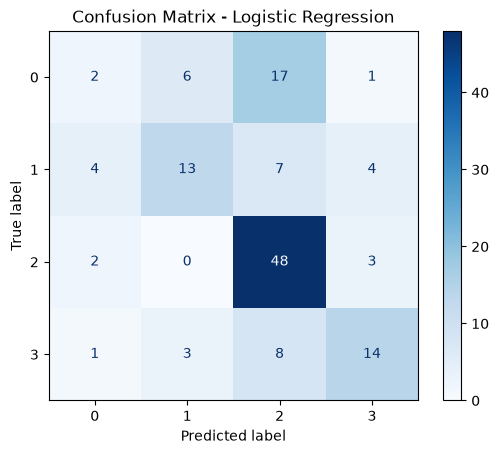


Training Naive Bayes...
Accuracy: 0.7820


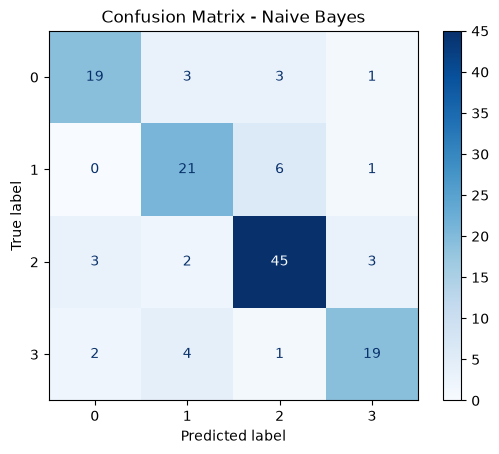


Training KNN...
Accuracy: 0.3835


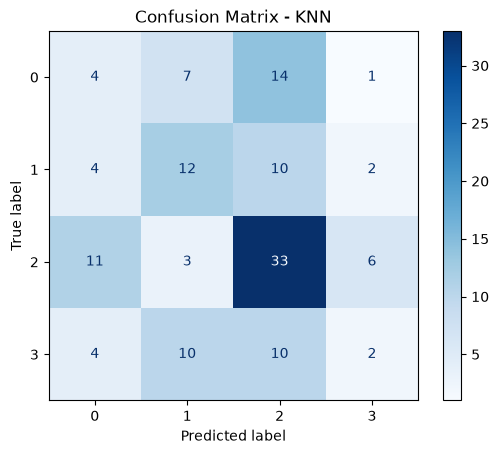


Training Decision Tree...
Accuracy: 0.7218


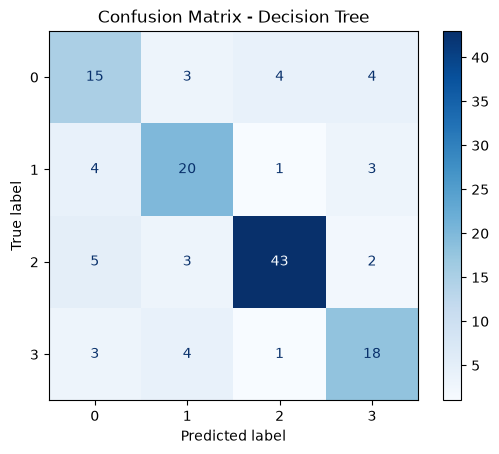


Training Random Forest...
Accuracy: 0.8045


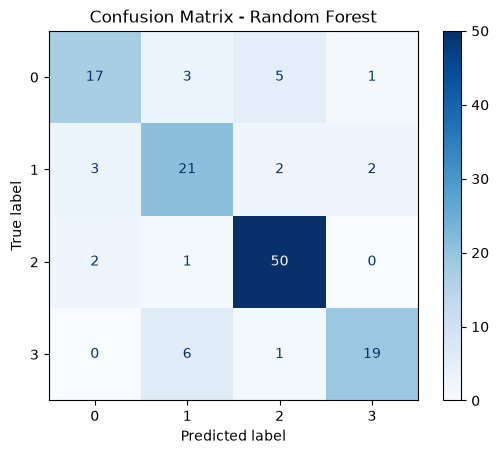


Training AdaBoost...
Accuracy: 0.8195


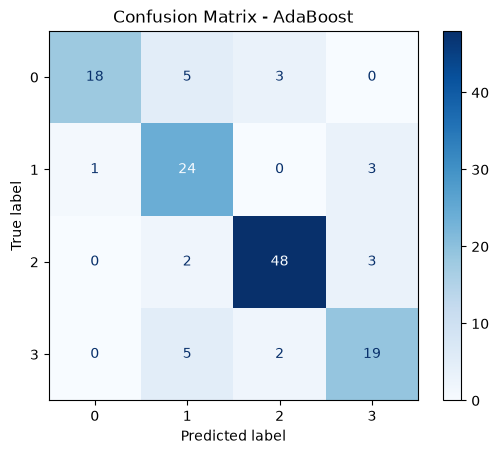


Training Gradient Boosting...
Accuracy: 0.8722


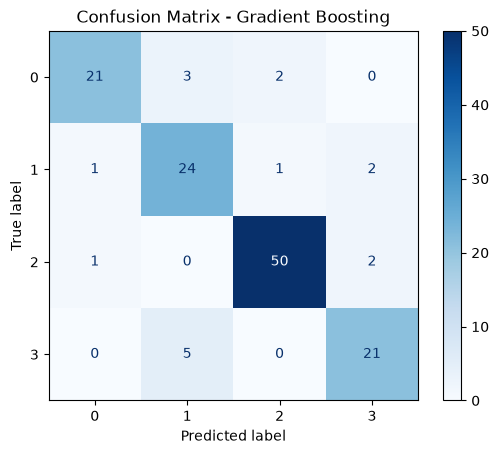


Training XGBoost...
Accuracy: 0.8496


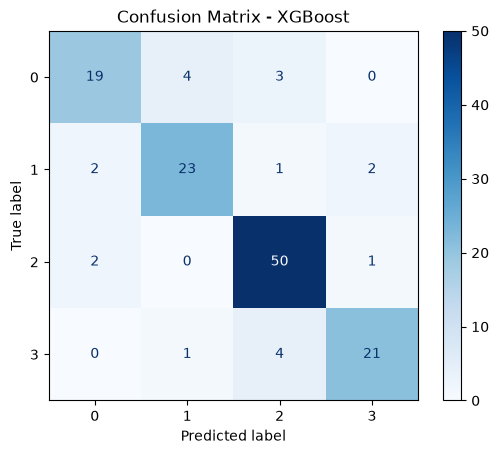


Training SVM...
Accuracy: 0.4586


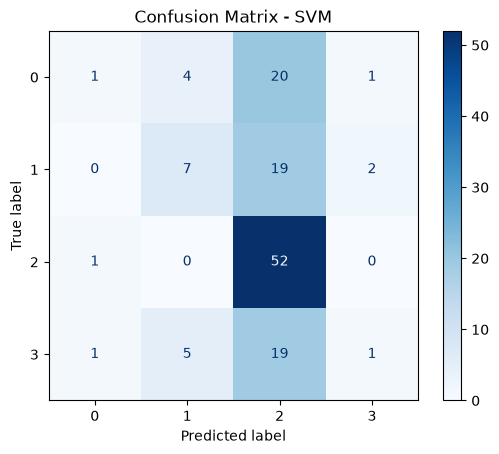


Training Neural Network...
Accuracy: 0.6692


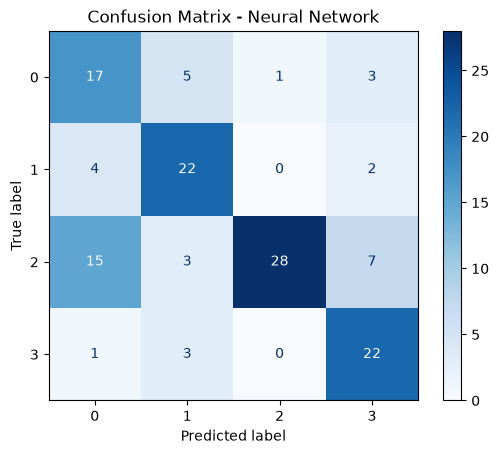

In [17]:
# Compare all models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"Accuracy: {accuracy:.4f}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d')

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [18]:
results_df1 = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df1)

                 Model  Accuracy
0  Logistic Regression  0.578947
1          Naive Bayes  0.781955
2                  KNN  0.383459
3        Decision Tree  0.721805
4        Random Forest  0.804511
5             AdaBoost  0.819549
6    Gradient Boosting  0.872180
7              XGBoost  0.849624
8                  SVM  0.458647
9       Neural Network  0.669173


In [19]:
best_model= max(results, key=results.get)
print(f"\n{'='*50}")
print("BEST MODEL:")
best_model_name = max(results, key=results.get)
print(f"{best_model} with accuracy: {results[best_model]:.4f}")


BEST MODEL:
Gradient Boosting with accuracy: 0.8722


In [20]:
results_df1 = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df1)

                 Model  Accuracy
0  Logistic Regression  0.578947
1          Naive Bayes  0.781955
2                  KNN  0.383459
3        Decision Tree  0.721805
4        Random Forest  0.804511
5             AdaBoost  0.819549
6    Gradient Boosting  0.872180
7              XGBoost  0.849624
8                  SVM  0.458647
9       Neural Network  0.669173


K-fold stratefication

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        estimator = Pipeline([("scaler", StandardScaler()), ("model", model)])
    else:
        estimator = model

    scores = cross_validate(
        estimator,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores['test_accuracy'].mean(),
        "Precision": scores['test_precision'].mean(),
        "Recall": scores['test_recall'].mean(),
        "F1-Score": scores['test_f1'].mean()
    })


In [22]:
results_df2 = pd.DataFrame(results)
print(results_df2)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.857849   0.862941  0.857849  0.856754
1          Naive Bayes  0.767077   0.767484  0.767077  0.763506
2                  KNN  0.726213   0.750802  0.726213  0.712949
3        Decision Tree  0.645979   0.649332  0.645979  0.646481
4        Random Forest  0.818501   0.817116  0.818501  0.813821
5             AdaBoost  0.767077   0.785908  0.767077  0.767808
6    Gradient Boosting  0.833630   0.831947  0.833630  0.831219
7              XGBoost  0.838186   0.838952  0.838186  0.836089
8                  SVM  0.820016   0.824912  0.820016  0.818012
9       Neural Network  0.841183   0.842603  0.841183  0.839650


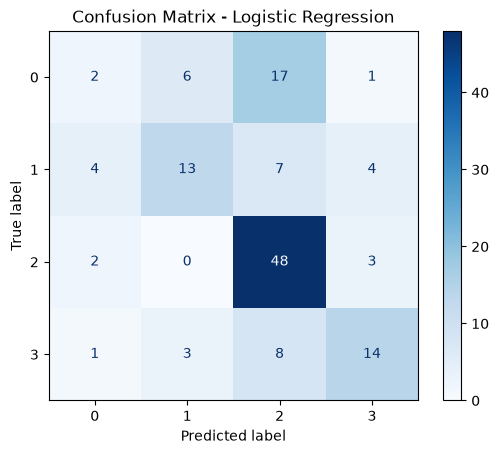

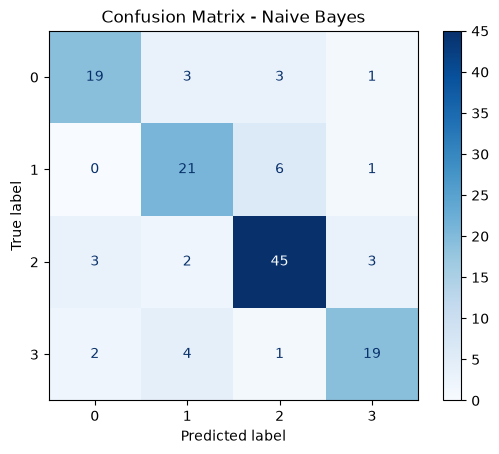

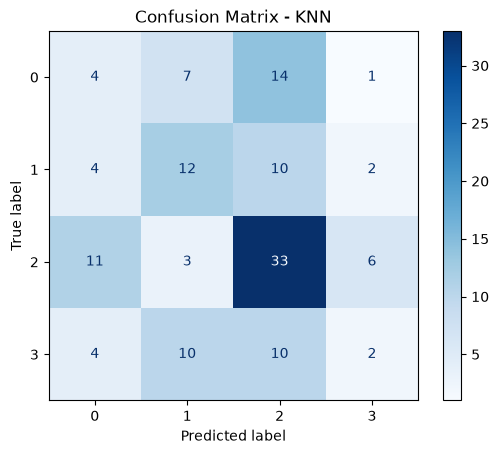

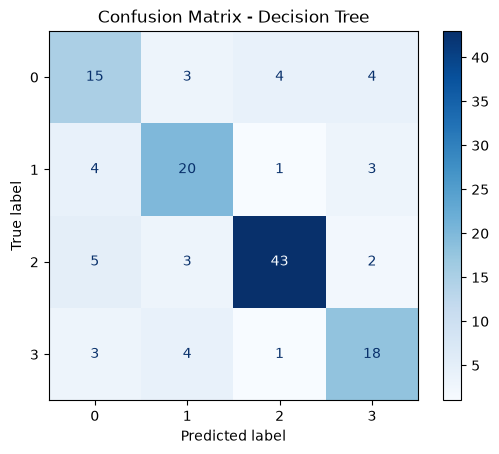

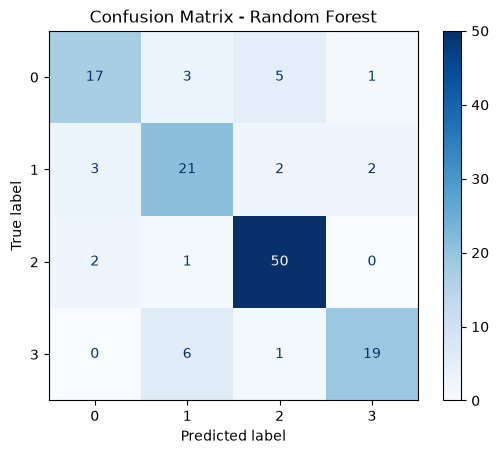

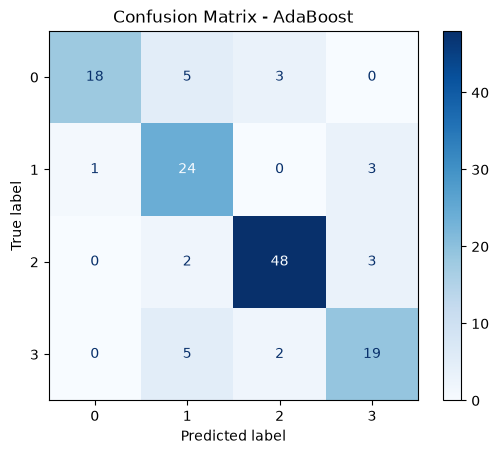

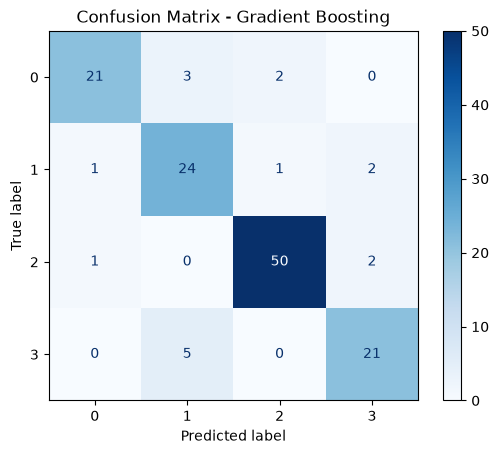

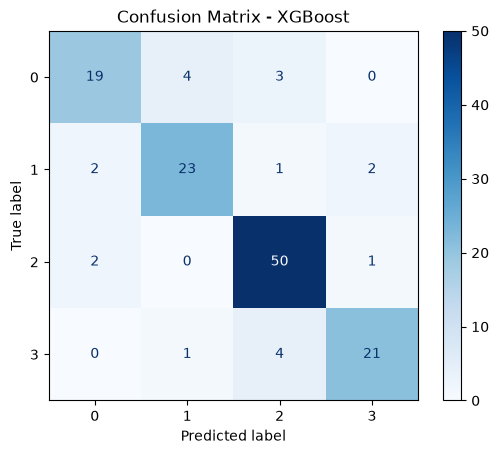

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# confusion matrix
for name, model in models.items():
    y_pred = model.predict(X_test)          # you'll also need this — see note below
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()